In [1]:
# 06_signals.ipynb
# Collect additional risk signals — Put/Call Ratio + sector correlation

import pandas as pd
import numpy as np
import yfinance as yf
import os
import matplotlib.pyplot as plt

data_path = os.path.expanduser("~/Desktop/SentriVaR-500/data")

# Load saved price data
prices = pd.read_csv(f"{data_path}/prices.csv", index_col="Date", parse_dates=True)
returns = prices.pct_change().dropna()

print("Loaded")
print(f"Price data: {prices.shape}")

Loaded
Price data: (2141, 5)


In [2]:
# Use ^CPC (CBOE Total Put/Call Ratio) instead of ^PCCE
pcr = yf.download("^CPC", start="2018-01-01", auto_adjust=True, progress=False)["Close"]
pcr.name = "PCR"
pcr = pcr.dropna()

if pcr.empty:
    # Fall back to ^CPCE
    pcr = yf.download("^CPCE", start="2018-01-01", auto_adjust=True, progress=False)["Close"]
    pcr.name = "PCR"
    pcr = pcr.dropna()

print(f"Put/Call Ratio data: {pcr.shape}")
if not pcr.empty:
    print(f"Date range: {pcr.index[0].date()} ~ {pcr.index[-1].date()}")
    print(f"Current value: {pcr.iloc[-1]:.3f}")
else:
    print("No data — need an alternative")

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^CPC"}}}
$^CPC: possibly delisted; no timezone found

1 Failed download:
['^CPC']: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^CPCE"}}}
$^CPCE: possibly delisted; no timezone found

1 Failed download:
['^CPCE']: possibly delisted; no timezone found


Put/Call Ratio data: (0, 1)
No data — need an alternative


In [3]:
# Use sector ETF correlation instead of Put/Call Ratio
# Key sector ETFs
SECTOR_ETFS = {
    "Tech":          "XLK",
    "Finance":       "XLF", 
    "Healthcare":    "XLV",
    "Energy":        "XLE",
    "Consumer":      "XLY",
    "Utilities":     "XLU",
    "Semiconductor": "SOXX"
}

# Fetch sector ETF data
sector_df = yf.download(
    list(SECTOR_ETFS.values()),
    start="2018-01-01",
    auto_adjust=True,
    progress=False
)["Close"]
sector_df.columns = list(SECTOR_ETFS.keys())
sector_df = sector_df.dropna()
sector_returns = sector_df.pct_change().dropna()

print(f"Sector data: {sector_df.shape}")
print(f"Date range: {sector_df.index[0].date()} ~ {sector_df.index[-1].date()}")

Sector data: (2141, 7)
Date range: 2018-01-02 ~ 2026-07-10


In [4]:
# Detect abnormal correlation between sectors
# Sectors normally move independently, but converge sharply in a crisis.
# The goal is to catch that convergence early.
def calculate_correlation_risk(sector_returns, window=30):
    """
    30-day rolling average correlation.
    Higher average correlation = sectors converging = crisis signal.
    """
    rolling_corr = []
    dates = []

    for i in range(window, len(sector_returns)):
        window_data = sector_returns.iloc[i-window:i]
        corr_matrix = window_data.corr()
        # Average correlation, excluding diagonal
        mask = np.ones(corr_matrix.shape, dtype=bool)
        np.fill_diagonal(mask, False)
        avg_corr = corr_matrix.values[mask].mean()
        rolling_corr.append(avg_corr)
        dates.append(sector_returns.index[i])

    return pd.Series(rolling_corr, index=dates, name="avg_correlation")

corr_risk = calculate_correlation_risk(sector_returns)

print(f"Correlation risk series: {corr_risk.shape}")
print(f"\nStats:")
print(f"  Mean: {corr_risk.mean():.3f}")
print(f"  Max:  {corr_risk.max():.3f} (max convergence — crisis)")
print(f"  Min:  {corr_risk.min():.3f} (independent — stable)")
print(f"\nCurrent value: {corr_risk.iloc[-1]:.3f}")
print(f"  → {'risky (converged)' if corr_risk.iloc[-1] > 0.7 else 'stable (independent)'}")

Correlation risk series: (2110,)

Stats:
  Mean: 0.438
  Max:  0.926 (max convergence — crisis)
  Min:  0.006 (independent — stable)

Current value: 0.008
  → stable (independent)


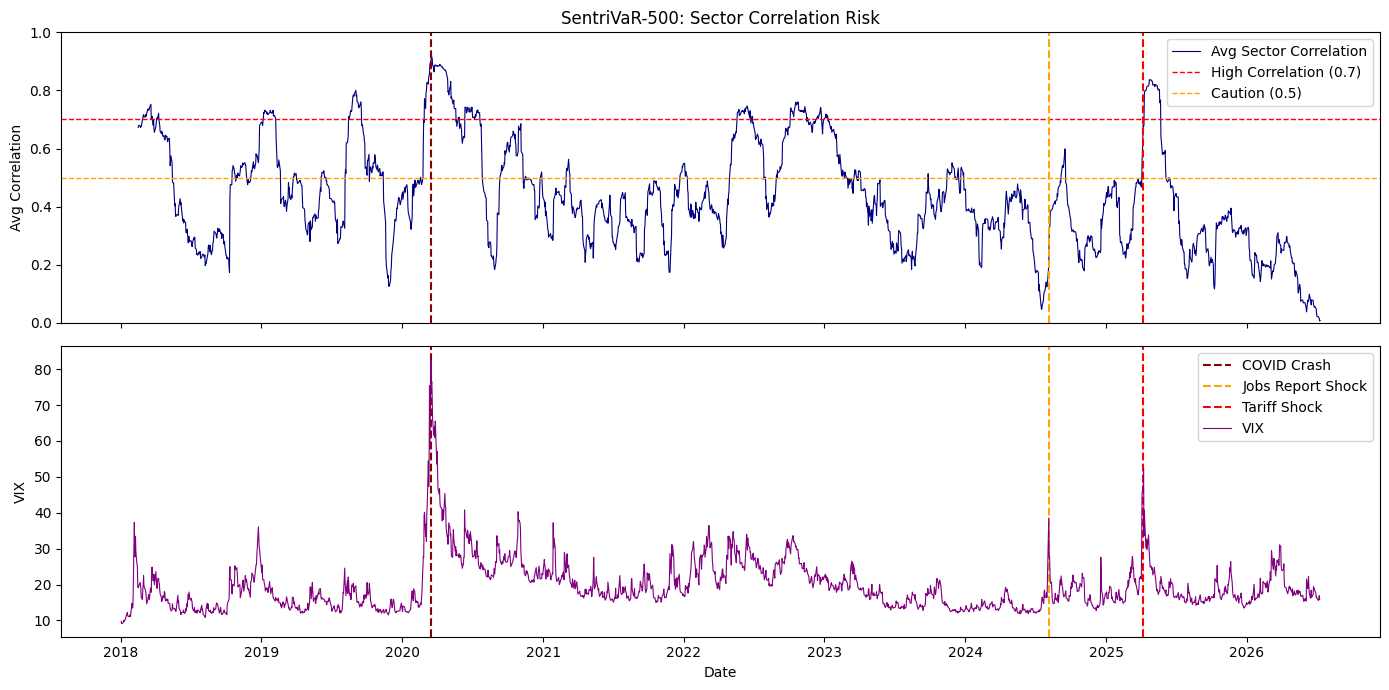

Saved: correlation_risk.png


In [5]:
# Visualize correlation risk vs VIX
macro = pd.read_csv(f"{data_path}/macro_daily.csv", index_col="DATE", parse_dates=True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Average sector correlation
ax1.plot(corr_risk.index, corr_risk, color="navy", linewidth=0.8, label="Avg Sector Correlation")
ax1.axhline(0.7, color="red", linestyle="--", linewidth=1, label="High Correlation (0.7)")
ax1.axhline(0.5, color="orange", linestyle="--", linewidth=1, label="Caution (0.5)")
ax1.set_ylabel("Avg Correlation")
ax1.set_title("SentriVaR-500: Sector Correlation Risk")
ax1.set_ylim(0, 1)
ax1.legend(loc="upper right")

# Case study events
for ax in [ax1, ax2]:
    ax.axvline(pd.Timestamp("2020-03-16"), color="darkred",
               linestyle="--", linewidth=1.5, label="COVID Crash")
    ax.axvline(pd.Timestamp("2024-08-05"), color="orange",
               linestyle="--", linewidth=1.5, label="Jobs Report Shock")
    ax.axvline(pd.Timestamp("2025-04-07"), color="red",
               linestyle="--", linewidth=1.5, label="Tariff Shock")

# VIX
ax2.plot(macro.index, macro["VIX"], color="purple", linewidth=0.8, label="VIX")
ax2.set_ylabel("VIX")
ax2.set_xlabel("Date")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"{data_path}/correlation_risk.png", dpi=150)
plt.show()
print("Saved: correlation_risk.png")